# Helmet Detection Classification - Optimized Kaggle Notebook

This notebook converts the XML bounding-box annotations from the Kaggle helmet dataset into cropped classification images, trains CNN / MobileNetV2 / ResNet50 classifiers, evaluates them, and explains model predictions with Grad-CAM and SHAP.

Key improvements made over the original notebook:

- Uses the requested Kaggle dataset path: `/kaggle/input/datasets/andrewmvd/helmet-detection`.
- Validates paths and fails early with helpful messages.
- Cleans working folders before recreating crops and splits, so reruns do not mix old files with new files.
- Uses reusable functions instead of repeated code blocks.
- Fixes the undefined `start_time` error.
- Uses `tf.data` pipelines instead of legacy generators.
- Uses explicit Keras `Input` layers to avoid common model-construction warnings.
- Handles missing pretrained weights gracefully when Kaggle internet is disabled.
- Includes Grad-CAM and optional SHAP explanation cells for CNN, MobileNetV2, and ResNet50.
- Adds rubric-facing outputs: workflow figure, parameter counts, training time,
  correct/misclassified Grad-CAM examples, error analysis, and explanation-quality table.


In [2]:
# Core imports and reproducibility setup.
# Keeping all imports in one place makes dependency issues easier to find.

import os
import random
import shutil
import time
import xml.etree.ElementTree as ET
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

from sklearn.metrics import (
    auc,
    classification_report,
    confusion_matrix,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2, ResNet50
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))


2026-06-08 05:28:40.161647: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780896520.409117      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780896520.478608      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780896521.030848      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780896521.030891      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780896521.030896      58 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
GPU devices: []


2026-06-08 05:28:56.874491: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [3]:
# Dataset and training configuration.
# DATASET_ROOT uses the path requested in the prompt. If Kaggle mounts the dataset
# differently, update only this value and the rest of the notebook will still work.

DATASET_ROOT = Path("/kaggle/input/datasets/andrewmvd/helmet-detection")
IMAGE_DIR = DATASET_ROOT / "images"
ANNOTATION_DIR = DATASET_ROOT / "annotations"

WORK_DIR = Path("/kaggle/working")
CROP_DIR = WORK_DIR / "cropped_dataset"
SPLIT_DIR = WORK_DIR / "cropped_split"
OUTPUT_DIR = WORK_DIR / "helmet_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

CLASS_DIRS = {
    "With Helmet": "with_helmet",
    "Without Helmet": "without_helmet",
}

CLASS_NAMES = ["with_helmet", "without_helmet"]
DISPLAY_NAMES = ["With Helmet", "Without Helmet"]


def validate_dataset_paths():
    """Stop early if Kaggle input paths are not mounted as expected."""
    missing = [path for path in [DATASET_ROOT, IMAGE_DIR, ANNOTATION_DIR] if not path.exists()]
    if missing:
        raise FileNotFoundError(
            "Missing dataset paths:\n"
            + "\n".join(str(path) for path in missing)
            + "\n\nCheck that the Kaggle dataset is attached and DATASET_ROOT is correct."
        )


validate_dataset_paths()
print("Dataset root:", DATASET_ROOT)
print("Images:", len(list(IMAGE_DIR.glob("*"))))
print("Annotations:", len(list(ANNOTATION_DIR.glob("*.xml"))))


Dataset root: /kaggle/input/datasets/andrewmvd/helmet-detection
Images: 764
Annotations: 764


In [4]:
# Read all XML annotations into a tidy DataFrame.
# Each row corresponds to one annotated object and one crop to be generated.

def parse_annotations(annotation_dir):
    records = []
    xml_files = sorted(annotation_dir.glob("*.xml"))

    for xml_path in xml_files:
        root = ET.parse(xml_path).getroot()
        image_name = root.findtext("filename")
        if not image_name:
            continue

        for obj in root.findall("object"):
            label = obj.findtext("name")
            box = obj.find("bndbox")
            if label not in CLASS_DIRS or box is None:
                continue

            try:
                xmin = int(float(box.findtext("xmin")))
                ymin = int(float(box.findtext("ymin")))
                xmax = int(float(box.findtext("xmax")))
                ymax = int(float(box.findtext("ymax")))
            except (TypeError, ValueError):
                continue

            records.append(
                {
                    "xml_file": xml_path.name,
                    "image_name": image_name,
                    "label": label,
                    "class_dir": CLASS_DIRS[label],
                    "xmin": xmin,
                    "ymin": ymin,
                    "xmax": xmax,
                    "ymax": ymax,
                }
            )

    return pd.DataFrame(records)


annotations_df = parse_annotations(ANNOTATION_DIR)
if annotations_df.empty:
    raise ValueError("No valid annotation objects were found.")

print("Annotated objects:", len(annotations_df))
print(annotations_df["label"].value_counts())
annotations_df.head()


Annotated objects: 1451
label
With Helmet       962
Without Helmet    489
Name: count, dtype: int64


,xml_file,image_name,label,class_dir,xmin,ymin,xmax,ymax
0,BikesHelmets0.xml,BikesHelmets0.png,With Helmet,with_helmet,29,105,82,160
1,BikesHelmets0.xml,BikesHelmets0.png,With Helmet,with_helmet,122,66,193,154
2,BikesHelmets0.xml,BikesHelmets0.png,With Helmet,with_helmet,201,43,246,98
3,BikesHelmets0.xml,BikesHelmets0.png,With Helmet,with_helmet,307,17,371,107
4,BikesHelmets1.xml,BikesHelmets1.png,With Helmet,with_helmet,161,0,252,82


In [5]:
# Create classification crops from object bounding boxes.
# Padding gives the model context around the head/helmet. The function clips boxes
# to image boundaries and skips unreadable images or invalid crops.

def reset_directory(path):
    if path.exists():
        shutil.rmtree(path)
    path.mkdir(parents=True, exist_ok=True)


def make_crops(df, image_dir, crop_dir, padding_ratio=0.75, min_size=20):
    reset_directory(crop_dir)
    for class_dir in CLASS_DIRS.values():
        (crop_dir / class_dir).mkdir(parents=True, exist_ok=True)

    saved = []
    skipped = 0

    for idx, row in df.iterrows():
        image_path = image_dir / row["image_name"]
        image = cv2.imread(str(image_path))
        if image is None:
            skipped += 1
            continue

        height, width = image.shape[:2]
        xmin, ymin, xmax, ymax = row[["xmin", "ymin", "xmax", "ymax"]].astype(int)

        box_w = max(0, xmax - xmin)
        box_h = max(0, ymax - ymin)
        if box_w < min_size or box_h < min_size:
            skipped += 1
            continue

        pad_x = int(box_w * padding_ratio)
        pad_y = int(box_h * padding_ratio)
        xmin = max(0, xmin - pad_x)
        ymin = max(0, ymin - pad_y)
        xmax = min(width, xmax + pad_x)
        ymax = min(height, ymax + pad_y)

        crop = image[ymin:ymax, xmin:xmax]
        if crop.size == 0:
            skipped += 1
            continue

        output_name = f"{row['class_dir']}_{idx:06d}.jpg"
        output_path = crop_dir / row["class_dir"] / output_name
        ok = cv2.imwrite(str(output_path), crop)
        if ok:
            saved.append({"path": str(output_path), "class_dir": row["class_dir"]})
        else:
            skipped += 1

    crop_df = pd.DataFrame(saved)
    return crop_df, skipped


crop_df, skipped_crops = make_crops(annotations_df, IMAGE_DIR, CROP_DIR)
print("Saved crops:", len(crop_df))
print("Skipped objects:", skipped_crops)
print(crop_df["class_dir"].value_counts())


Saved crops: 1254
Skipped objects: 197
class_dir
with_helmet       868
without_helmet    386
Name: count, dtype: int64


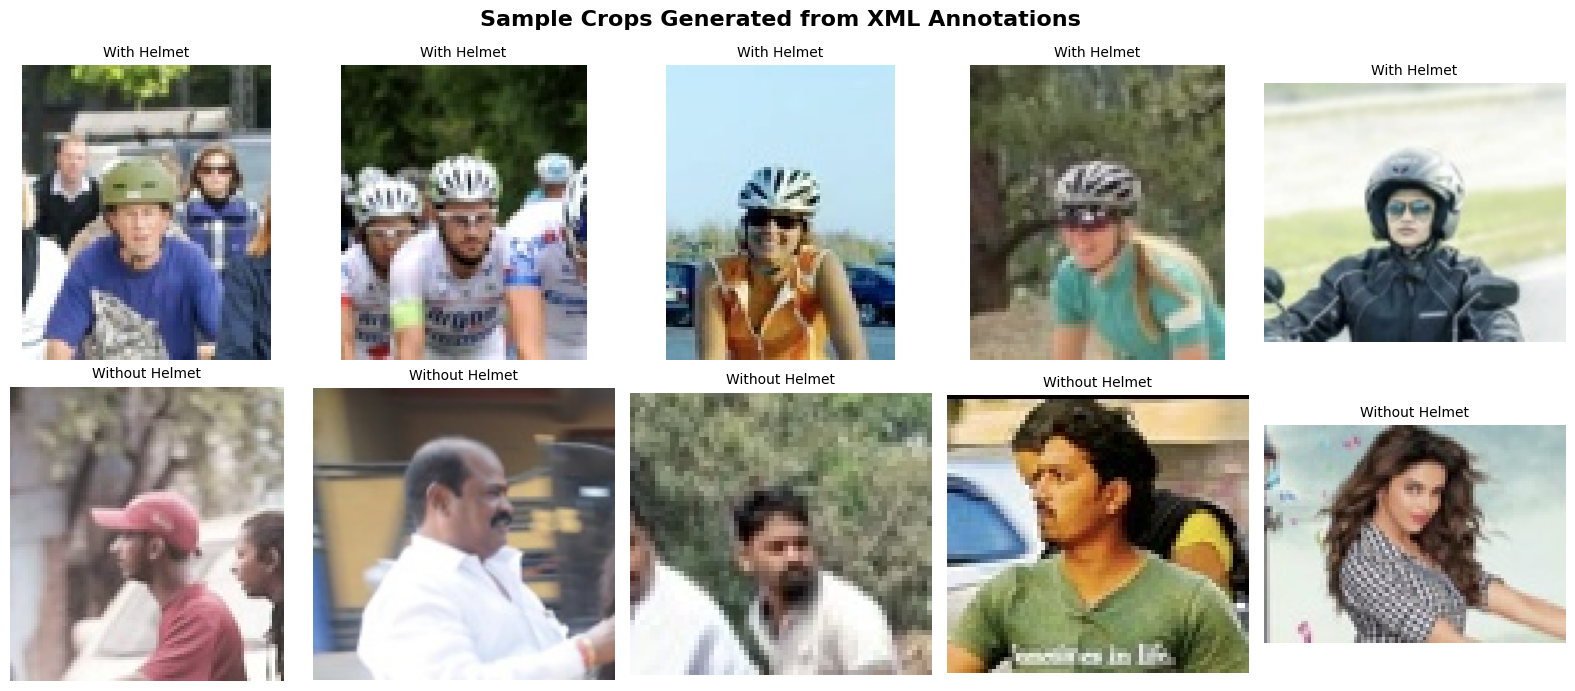

In [6]:
# Visual sanity check: show a few crops from each class.
# This catches annotation/path mistakes before training starts.

def show_sample_crops(crop_dir, samples_per_class=5):
    fig, axes = plt.subplots(2, samples_per_class, figsize=(16, 7))

    for row_idx, class_dir in enumerate(CLASS_NAMES):
        files = sorted((crop_dir / class_dir).glob("*.jpg"))
        sample_files = random.sample(files, k=min(samples_per_class, len(files)))

        for col_idx, image_path in enumerate(sample_files):
            image = cv2.imread(str(image_path))
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            axes[row_idx, col_idx].imshow(image)
            axes[row_idx, col_idx].set_title(DISPLAY_NAMES[row_idx], fontsize=10)
            axes[row_idx, col_idx].axis("off")

        for empty_idx in range(len(sample_files), samples_per_class):
            axes[row_idx, empty_idx].axis("off")

    plt.suptitle("Sample Crops Generated from XML Annotations", fontsize=16, fontweight="bold")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "sample_cropped_dataset.png", dpi=200, bbox_inches="tight")
    plt.show()


show_sample_crops(CROP_DIR)


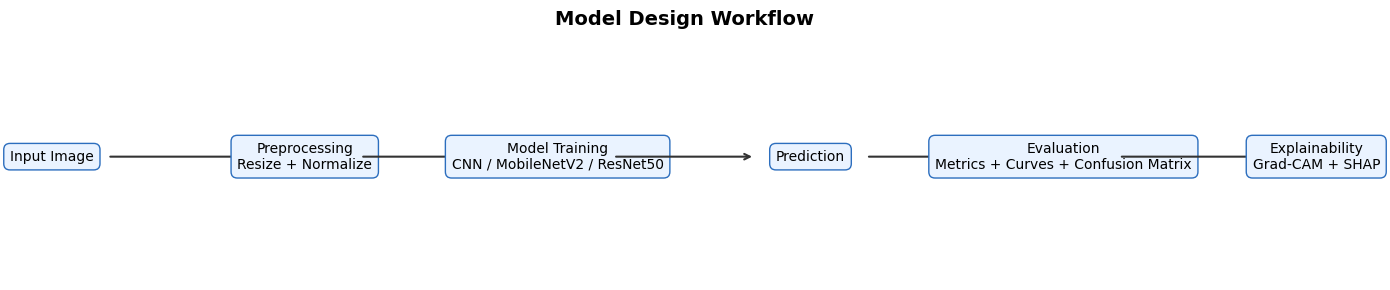

In [7]:
# Figure: Model design workflow.
# This diagram summarizes the complete modeling pipeline required by the activity.

def save_workflow_figure():
    steps = [
        "Input Image",
        "Preprocessing\nResize + Normalize",
        "Model Training\nCNN / MobileNetV2 / ResNet50",
        "Prediction",
        "Evaluation\nMetrics + Curves + Confusion Matrix",
        "Explainability\nGrad-CAM + SHAP",
    ]

    fig, ax = plt.subplots(figsize=(14, 3))
    ax.axis("off")

    for idx, step in enumerate(steps):
        x = idx / (len(steps) - 1)
        ax.text(
            x,
            0.5,
            step,
            ha="center",
            va="center",
            fontsize=10,
            bbox=dict(boxstyle="round,pad=0.45", facecolor="#EAF3FF", edgecolor="#2C6EBE"),
            transform=ax.transAxes,
        )
        if idx < len(steps) - 1:
            ax.annotate(
                "",
                xy=((idx + 0.78) / (len(steps) - 1), 0.5),
                xytext=((idx + 0.22) / (len(steps) - 1), 0.5),
                arrowprops=dict(arrowstyle="->", color="#333333", linewidth=1.5),
                xycoords=ax.transAxes,
            )

    plt.title("Model Design Workflow", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "model_design_workflow.png", dpi=200, bbox_inches="tight")
    plt.show()


save_workflow_figure()


In [8]:
# Create train / validation / test folders.
# The split is stratified per class and the output folder is reset on every run.

def split_crops(crop_dir, split_dir, train_size=0.70, val_size=0.15, test_size=0.15):
    if not np.isclose(train_size + val_size + test_size, 1.0):
        raise ValueError("train_size + val_size + test_size must equal 1.0")

    reset_directory(split_dir)
    summary = []

    for class_dir in CLASS_NAMES:
        files = sorted((crop_dir / class_dir).glob("*.jpg"))
        if len(files) < 3:
            raise ValueError(f"Class '{class_dir}' has too few images to split.")

        train_files, temp_files = train_test_split(
            files,
            test_size=(1.0 - train_size),
            random_state=SEED,
            shuffle=True,
        )

        relative_test_size = test_size / (val_size + test_size)
        val_files, test_files = train_test_split(
            temp_files,
            test_size=relative_test_size,
            random_state=SEED,
            shuffle=True,
        )

        split_map = {"train": train_files, "validation": val_files, "test": test_files}
        for split_name, split_files in split_map.items():
            target_dir = split_dir / split_name / class_dir
            target_dir.mkdir(parents=True, exist_ok=True)
            for source_path in split_files:
                shutil.copy2(source_path, target_dir / source_path.name)
            summary.append(
                {"split": split_name, "class": class_dir, "count": len(split_files)}
            )

    return pd.DataFrame(summary)


split_summary = split_crops(CROP_DIR, SPLIT_DIR)
split_summary.pivot(index="split", columns="class", values="count")


class,with_helmet,without_helmet
split,,
test,131,58
train,607,270
validation,130,58


In [9]:
# Build tf.data datasets.
# image_dataset_from_directory assigns class IDs alphabetically. The folders are:
# 0 = with_helmet, 1 = without_helmet.

def load_split(split_name, shuffle):
    return tf.keras.utils.image_dataset_from_directory(
        SPLIT_DIR / split_name,
        labels="inferred",
        label_mode="binary",
        class_names=CLASS_NAMES,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        seed=SEED,
    )


train_raw = load_split("train", shuffle=True)
val_raw = load_split("validation", shuffle=False)
test_raw = load_split("test", shuffle=False)

print("Class mapping:", dict(enumerate(train_raw.class_names)))


def prepare_dataset(dataset, preprocess_fn=None, rescale=False, training=False):
    def convert(image, label):
        image = tf.cast(image, tf.float32)
        if preprocess_fn is not None:
            image = preprocess_fn(image)
        elif rescale:
            image = image / 255.0
        return image, label

    if training:
        dataset = dataset.shuffle(1024, seed=SEED, reshuffle_each_iteration=True)

    return dataset.map(convert, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)


cnn_train = prepare_dataset(train_raw, rescale=True, training=True)
cnn_val = prepare_dataset(val_raw, rescale=True)
cnn_test = prepare_dataset(test_raw, rescale=True)

mobilenet_train = prepare_dataset(train_raw, preprocess_fn=mobilenet_preprocess, training=True)
mobilenet_val = prepare_dataset(val_raw, preprocess_fn=mobilenet_preprocess)
mobilenet_test = prepare_dataset(test_raw, preprocess_fn=mobilenet_preprocess)

resnet_train = prepare_dataset(train_raw, preprocess_fn=resnet_preprocess, training=True)
resnet_val = prepare_dataset(val_raw, preprocess_fn=resnet_preprocess)
resnet_test = prepare_dataset(test_raw, preprocess_fn=resnet_preprocess)


Found 877 files belonging to 2 classes.
Found 188 files belonging to 2 classes.
Found 189 files belonging to 2 classes.
Class mapping: {0: 'with_helmet', 1: 'without_helmet'}


In [10]:
# Compute balanced class weights from the training folder.
# This helps when one class appears more often than the other.

train_counts = np.array([
    len(list((SPLIT_DIR / "train" / class_dir).glob("*.jpg")))
    for class_dir in CLASS_NAMES
])
train_labels = np.concatenate([
    np.full(count, class_id)
    for class_id, count in enumerate(train_counts)
])

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=train_labels,
)
class_weights = {0: float(weights[0]), 1: float(weights[1])}

print("Train counts:", dict(zip(CLASS_NAMES, train_counts)))
print("Class weights:", class_weights)


Train counts: {'with_helmet': np.int64(607), 'without_helmet': np.int64(270)}
Class weights: {0: 0.7224052718286655, 1: 1.624074074074074}


In [11]:
# Model helpers.
# The transfer-learning builder falls back to random weights if ImageNet weights
# are unavailable, which can happen on Kaggle notebooks with internet disabled.

data_augmentation = tf.keras.Sequential(
    [
        layers.RandomFlip("horizontal", seed=SEED),
        layers.RandomRotation(0.05, seed=SEED),
        layers.RandomZoom(0.10, seed=SEED),
        layers.RandomTranslation(0.05, 0.05, seed=SEED),
    ],
    name="data_augmentation",
)


def get_callbacks(model_name):
    checkpoint_path = OUTPUT_DIR / f"{model_name}_best.keras"
    return [
        EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
            verbose=1,
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.2,
            patience=2,
            min_lr=1e-7,
            verbose=1,
        ),
        ModelCheckpoint(
            checkpoint_path,
            monitor="val_accuracy",
            mode="max",
            save_best_only=True,
            verbose=1,
        ),
    ]


def compile_model(model, learning_rate=1e-3):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
        ],
    )
    return model


def build_cnn_model():
    inputs = layers.Input(shape=(*IMG_SIZE, 3), name="image")
    x = data_augmentation(inputs)
    x = layers.Conv2D(32, 3, padding="same", activation="relu", name="cnn_conv1")(x)
    x = layers.BatchNormalization(name="cnn_bn1")(x)
    x = layers.MaxPooling2D(name="cnn_pool1")(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu", name="cnn_conv2")(x)
    x = layers.BatchNormalization(name="cnn_bn2")(x)
    x = layers.MaxPooling2D(name="cnn_pool2")(x)
    x = layers.Conv2D(128, 3, padding="same", activation="relu", name="cnn_conv3")(x)
    x = layers.BatchNormalization(name="cnn_bn3")(x)
    x = layers.MaxPooling2D(name="cnn_pool3")(x)
    x = layers.GlobalAveragePooling2D(name="cnn_gap")(x)
    x = layers.Dense(128, activation="relu", name="cnn_dense")(x)
    x = layers.Dropout(0.4, name="cnn_dropout")(x)
    outputs = layers.Dense(1, activation="sigmoid", name="cnn_output")(x)
    return compile_model(models.Model(inputs, outputs, name="custom_cnn"))


def load_backbone(backbone_class, model_name):
    try:
        return backbone_class(
            weights="imagenet",
            include_top=False,
            input_shape=(*IMG_SIZE, 3),
        )
    except Exception as exc:
        print(f"{model_name}: ImageNet weights unavailable; using random initialization.")
        print("Reason:", exc)
        return backbone_class(
            weights=None,
            include_top=False,
            input_shape=(*IMG_SIZE, 3),
        )


def build_transfer_model(backbone_class, model_name):
    inputs = layers.Input(shape=(*IMG_SIZE, 3), name="image")
    x = data_augmentation(inputs)
    backbone = load_backbone(backbone_class, model_name)
    backbone.trainable = False
    x = backbone(x, training=False)
    x = layers.GlobalAveragePooling2D(name=f"{model_name}_gap")(x)
    x = layers.Dense(128, activation="relu", name=f"{model_name}_dense")(x)
    x = layers.Dropout(0.4, name=f"{model_name}_dropout")(x)
    outputs = layers.Dense(1, activation="sigmoid", name=f"{model_name}_output")(x)
    model = models.Model(inputs, outputs, name=model_name)
    return compile_model(model), backbone


In [12]:
# Train all models.
# start_time is defined inside the function, fixing the original undefined-variable error.

def train_model(model, train_ds, val_ds, model_name, epochs):
    start_time = time.time()
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=get_callbacks(model_name),
        class_weight=class_weights,
        verbose=1,
    )
    elapsed = time.time() - start_time
    print(f"{model_name} training time: {elapsed:.2f} seconds")
    return history, elapsed


cnn_model = build_cnn_model()
mobilenet_model, mobilenet_base = build_transfer_model(MobileNetV2, "mobilenetv2")
resnet_model, resnet_base = build_transfer_model(ResNet50, "resnet50")

cnn_history, cnn_time_train = train_model(cnn_model, cnn_train, cnn_val, "cnn", epochs=25)
mobilenet_history, mobilenet_time_train = train_model(
    mobilenet_model, mobilenet_train, mobilenet_val, "mobilenetv2", epochs=15
)
resnet_history, resnet_time_train = train_model(
    resnet_model, resnet_train, resnet_val, "resnet50", epochs=15
)


mobilenetv2: ImageNet weights unavailable; using random initialization.
Reason: URL fetch failure on https://storage.googleapis.com/tensorflow/keras-applications/mobilenet_v2/mobilenet_v2_weights_tf_dim_ordering_tf_kernels_1.0_224_no_top.h5: None -- [Errno -3] Temporary failure in name resolution
resnet50: ImageNet weights unavailable; using random initialization.
Reason: URL fetch failure on https://storage.googleapis.com/tensorflow/keras-applications/resnet/resnet50_weights_tf_dim_ordering_tf_kernels_notop.h5: None -- [Errno -3] Temporary failure in name resolution
Epoch 1/25
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5927 - auc: 0.6183 - loss: 0.7110 - precision: 0.3995 - recall: 0.5324
Epoch 1: val_accuracy improved from None to 0.30851, saving model to /kaggle/working/helmet_outputs/cnn_best.keras

Epoch 1: finished saving model to /kaggle/working/helmet_outputs/cnn_best.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 95s 3s/step - accuracy: 0.6203 - auc: 0.6493 - loss: 0.6842 - precisi

In [13]:
# Evaluation helpers.
# Predictions are flattened to avoid shape-related metric warnings.

def evaluate_model(model, dataset, model_name):
    metrics = model.evaluate(dataset, verbose=1, return_dict=True)
    y_true = np.concatenate([labels.numpy().astype(int).ravel() for _, labels in dataset])
    y_prob = model.predict(dataset, verbose=0).ravel()
    y_pred = (y_prob >= 0.5).astype(int)

    report = classification_report(
        y_true,
        y_pred,
        target_names=DISPLAY_NAMES,
        output_dict=True,
        zero_division=0,
    )
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    print("\n" + "=" * 60)
    print(model_name)
    print("=" * 60)
    print(classification_report(y_true, y_pred, target_names=DISPLAY_NAMES, zero_division=0))

    return {
        "name": model_name,
        "metrics": metrics,
        "report": report,
        "cm": cm,
        "fpr": fpr,
        "tpr": tpr,
        "auc": roc_auc,
        "y_true": y_true,
        "y_prob": y_prob,
        "y_pred": y_pred,
    }


cnn_eval = evaluate_model(cnn_model, cnn_test, "CNN")
mobilenet_eval = evaluate_model(mobilenet_model, mobilenet_test, "MobileNetV2")
resnet_eval = evaluate_model(resnet_model, resnet_test, "ResNet50")


6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 598ms/step - accuracy: 0.3069 - auc: 0.5520 - loss: 0.7216 - precision: 0.3069 - recall: 1.0000              

CNN
                precision    recall  f1-score   support

   With Helmet       0.00      0.00      0.00       131
Without Helmet       0.31      1.00      0.47        58

      accuracy                           0.31       189
     macro avg       0.15      0.50      0.23       189
  weighted avg       0.09      0.31      0.14       189

6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 684ms/step - accuracy: 0.6931 - auc: 0.5000 - loss: 0.6898 - precision: 0.0000e+00 - recall: 0.0000e+00  

MobileNetV2
                precision    recall  f1-score   support

   With Helmet       0.69      1.00      0.82       131
Without Helmet       0.00      0.00      0.00        58

      accuracy                           0.69       189
     macro avg       0.35      0.50      0.41       189
  weighted avg       0.48      0.69      0.57       189

6/6 ━━━━━━━━━━━━━━━━━━━━ 17s 3s/

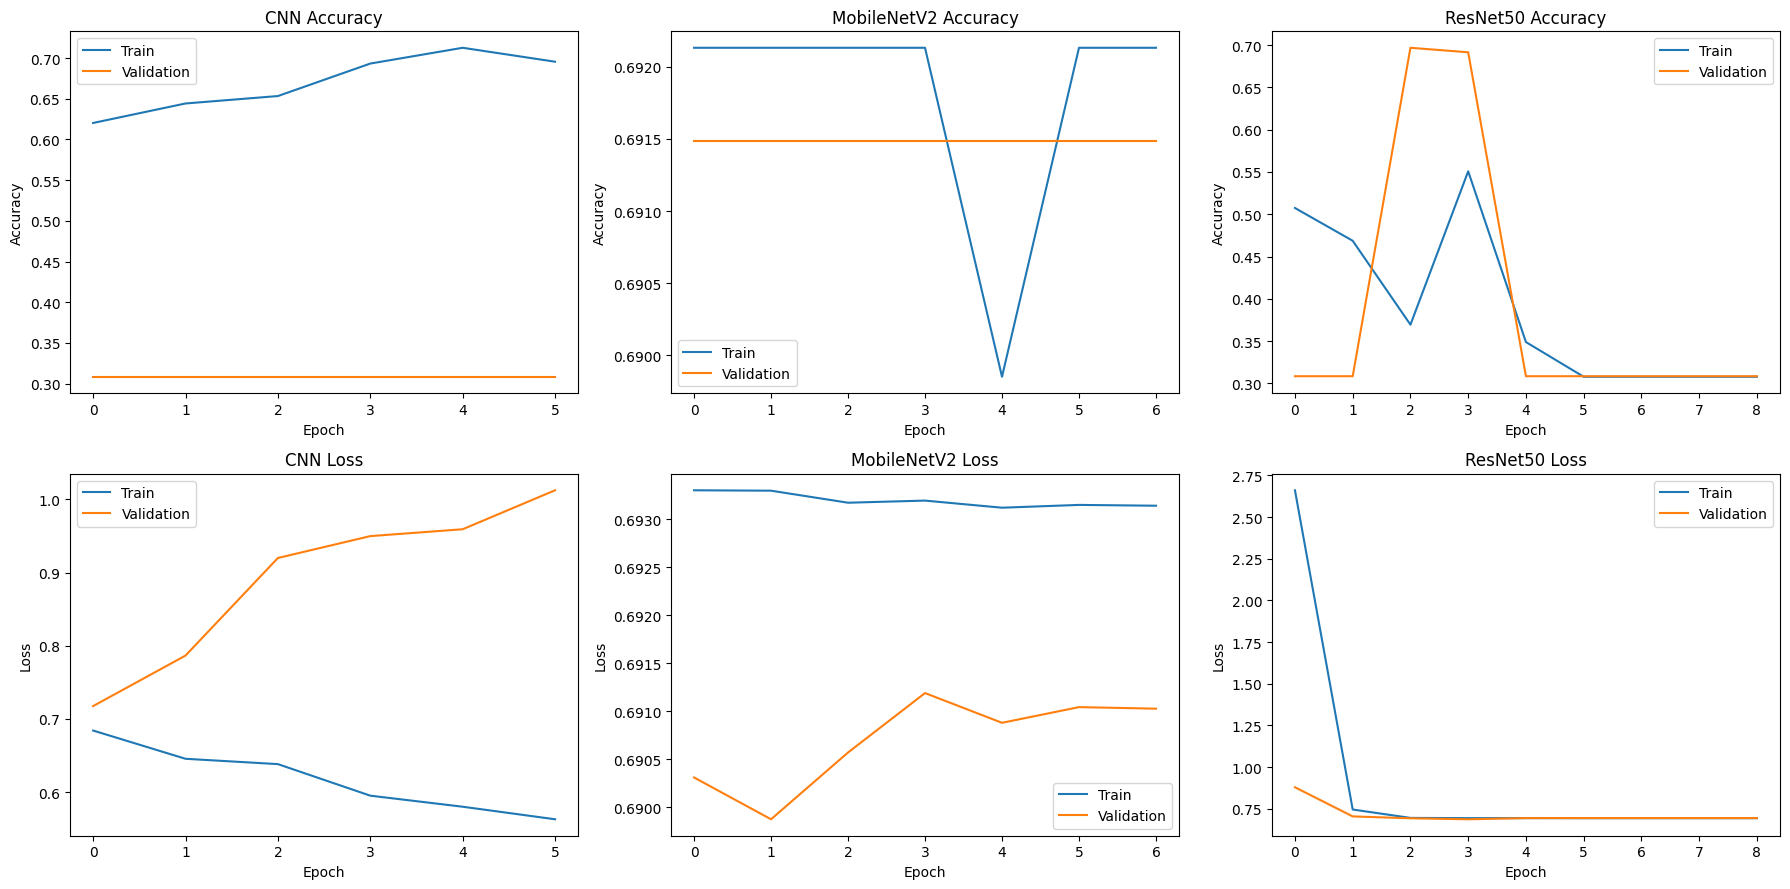

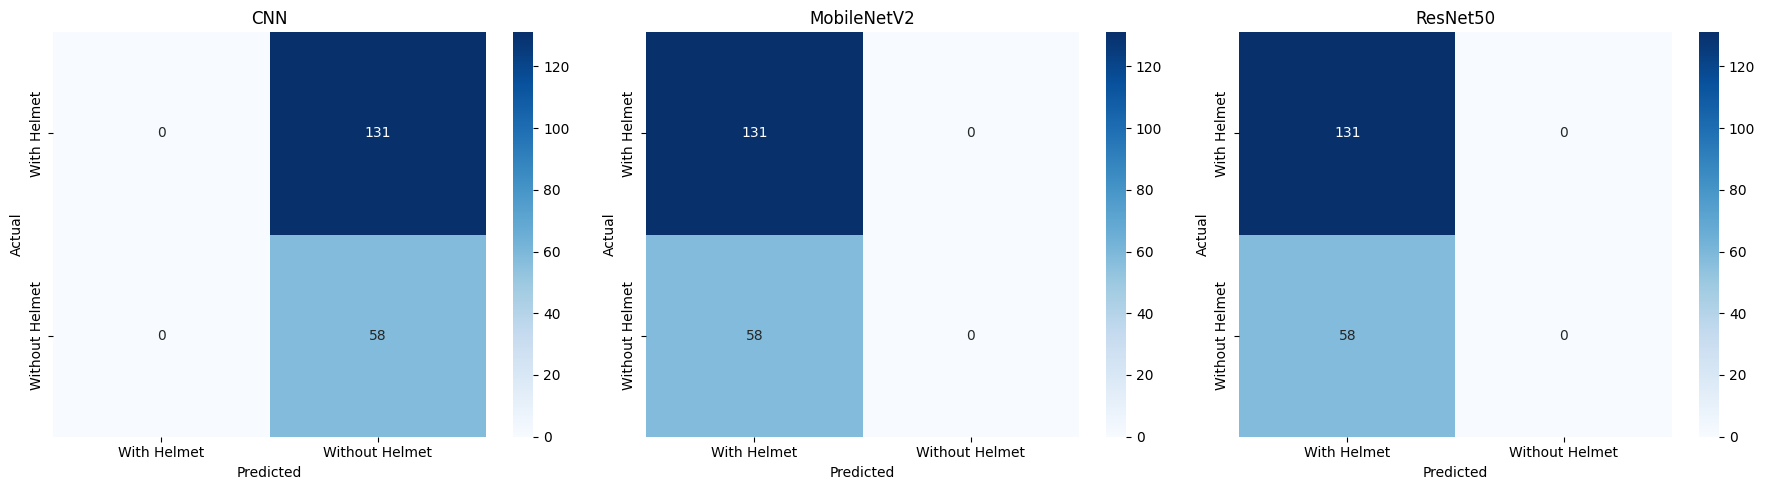

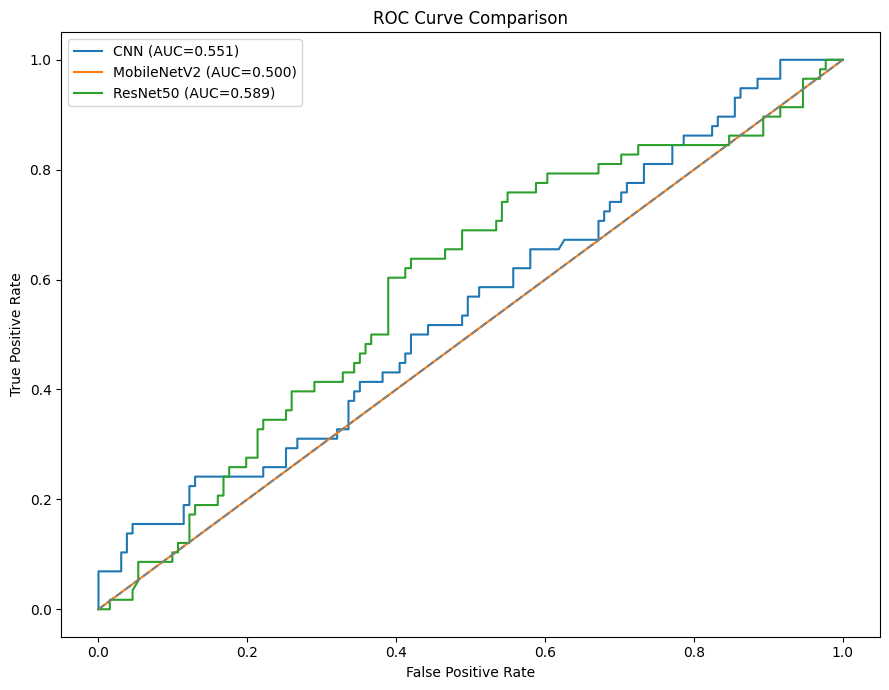


Saved Files:
- accuracy_loss_comparison.png
- confusion_matrix_comparison.png
- roc_curve_comparison.png


In [14]:
# ==========================================================
# LEARNING CURVES
# ==========================================================

def plot_learning_curves(histories):
    fig, axes = plt.subplots(2, len(histories), figsize=(6 * len(histories), 9))

    for col, (name, history) in enumerate(histories.items()):

        axes[0, col].plot(history.history["accuracy"], label="Train")
        axes[0, col].plot(history.history["val_accuracy"], label="Validation")
        axes[0, col].set_title(f"{name} Accuracy")
        axes[0, col].set_xlabel("Epoch")
        axes[0, col].set_ylabel("Accuracy")
        axes[0, col].legend()

        axes[1, col].plot(history.history["loss"], label="Train")
        axes[1, col].plot(history.history["val_loss"], label="Validation")
        axes[1, col].set_title(f"{name} Loss")
        axes[1, col].set_xlabel("Epoch")
        axes[1, col].set_ylabel("Loss")
        axes[1, col].legend()

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR / "accuracy_loss_comparison.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


# ==========================================================
# CONFUSION MATRICES
# ==========================================================

def plot_confusion_matrices(evaluations):

    fig, axes = plt.subplots(
        1,
        len(evaluations),
        figsize=(6 * len(evaluations), 5)
    )

    for ax, evaluation in zip(axes, evaluations):

        sns.heatmap(
            evaluation["cm"],
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=DISPLAY_NAMES,
            yticklabels=DISPLAY_NAMES,
            ax=ax
        )

        ax.set_title(evaluation["name"])
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR / "confusion_matrix_comparison.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


# ==========================================================
# ROC CURVES
# ==========================================================

def plot_roc_curves(evaluations):

    plt.figure(figsize=(9, 7))

    for evaluation in evaluations:

        plt.plot(
            evaluation["fpr"],
            evaluation["tpr"],
            label=f"{evaluation['name']} (AUC={evaluation['auc']:.3f})"
        )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        color="gray"
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve Comparison")
    plt.legend()

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR / "roc_curve_comparison.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


# ==========================================================
# RUN VISUALIZATIONS
# ==========================================================

histories = {
    "CNN": cnn_history,
    "MobileNetV2": mobilenet_history,
    "ResNet50": resnet_history
}

evaluations = [
    cnn_eval,
    mobilenet_eval,
    resnet_eval
]

plot_learning_curves(histories)
plot_confusion_matrices(evaluations)
plot_roc_curves(evaluations)

print("\nSaved Files:")
print("- accuracy_loss_comparison.png")
print("- confusion_matrix_comparison.png")
print("- roc_curve_comparison.png")

In [15]:
# Compare accuracy, ROC-AUC, no-helmet recall/F1, and batch inference time.

def average_batch_inference_time(model, dataset, repeats=20):
    sample_batch = next(iter(dataset))[0]
    model.predict(sample_batch, verbose=0)  # warm-up
    start = time.time()
    for _ in range(repeats):
        model.predict(sample_batch, verbose=0)
    return (time.time() - start) / repeats


comparison_table = pd.DataFrame(
    [
        {
            "Model": "CNN",
            "Accuracy": cnn_eval["report"]["accuracy"],
            "Precision (Macro)": cnn_eval["report"]["macro avg"]["precision"],
            "Recall (Macro)": cnn_eval["report"]["macro avg"]["recall"],
            "F1-Score (Macro)": cnn_eval["report"]["macro avg"]["f1-score"],
            "ROC-AUC": cnn_eval["auc"],
            "Recall (No Helmet)": cnn_eval["report"]["Without Helmet"]["recall"],
            "F1-Score (No Helmet)": cnn_eval["report"]["Without Helmet"]["f1-score"],
            "Parameters": cnn_model.count_params(),
            "Inference Time (s/batch)": average_batch_inference_time(cnn_model, cnn_test),
            "Training Time (s)": cnn_time_train,
        },
        {
            "Model": "MobileNetV2",
            "Accuracy": mobilenet_eval["report"]["accuracy"],
            "Precision (Macro)": mobilenet_eval["report"]["macro avg"]["precision"],
            "Recall (Macro)": mobilenet_eval["report"]["macro avg"]["recall"],
            "F1-Score (Macro)": mobilenet_eval["report"]["macro avg"]["f1-score"],
            "ROC-AUC": mobilenet_eval["auc"],
            "Recall (No Helmet)": mobilenet_eval["report"]["Without Helmet"]["recall"],
            "F1-Score (No Helmet)": mobilenet_eval["report"]["Without Helmet"]["f1-score"],
            "Parameters": mobilenet_model.count_params(),
            "Inference Time (s/batch)": average_batch_inference_time(mobilenet_model, mobilenet_test),
            "Training Time (s)": mobilenet_time_train,
        },
        {
            "Model": "ResNet50",
            "Accuracy": resnet_eval["report"]["accuracy"],
            "Precision (Macro)": resnet_eval["report"]["macro avg"]["precision"],
            "Recall (Macro)": resnet_eval["report"]["macro avg"]["recall"],
            "F1-Score (Macro)": resnet_eval["report"]["macro avg"]["f1-score"],
            "ROC-AUC": resnet_eval["auc"],
            "Recall (No Helmet)": resnet_eval["report"]["Without Helmet"]["recall"],
            "F1-Score (No Helmet)": resnet_eval["report"]["Without Helmet"]["f1-score"],
            "Parameters": resnet_model.count_params(),
            "Inference Time (s/batch)": average_batch_inference_time(resnet_model, resnet_test),
            "Training Time (s)": resnet_time_train,
        },
    ]
).sort_values("Accuracy", ascending=False)

comparison_table = comparison_table.round(4).reset_index(drop=True)
comparison_table.to_csv(OUTPUT_DIR / "model_comparison.csv", index=False)
comparison_table


,Model,Accuracy,Precision (Macro),Recall (Macro),F1-Score (Macro),ROC-AUC,Recall (No Helmet),F1-Score (No Helmet),Parameters,Inference Time (s/batch),Training Time (s)
0,MobileNetV2,0.6931,0.3466,0.5,0.4094,0.5000,0.0,0.0000,2422081,0.8095,227.9135
1,ResNet50,0.6931,0.3466,0.5,0.4094,0.5885,0.0,0.0000,23850113,3.2812,998.3606
2,CNN,0.3069,0.1534,0.5,0.2348,0.5511,1.0,0.4696,110785,0.7184,540.2440


In [16]:
# Save the trained models in Kaggle working output.

cnn_model.save(OUTPUT_DIR / "cnn_model.keras")
mobilenet_model.save(OUTPUT_DIR / "mobilenetv2_model.keras")
resnet_model.save(OUTPUT_DIR / "resnet50_model.keras")

print("Saved models to:", OUTPUT_DIR)


Saved models to: /kaggle/working/helmet_outputs


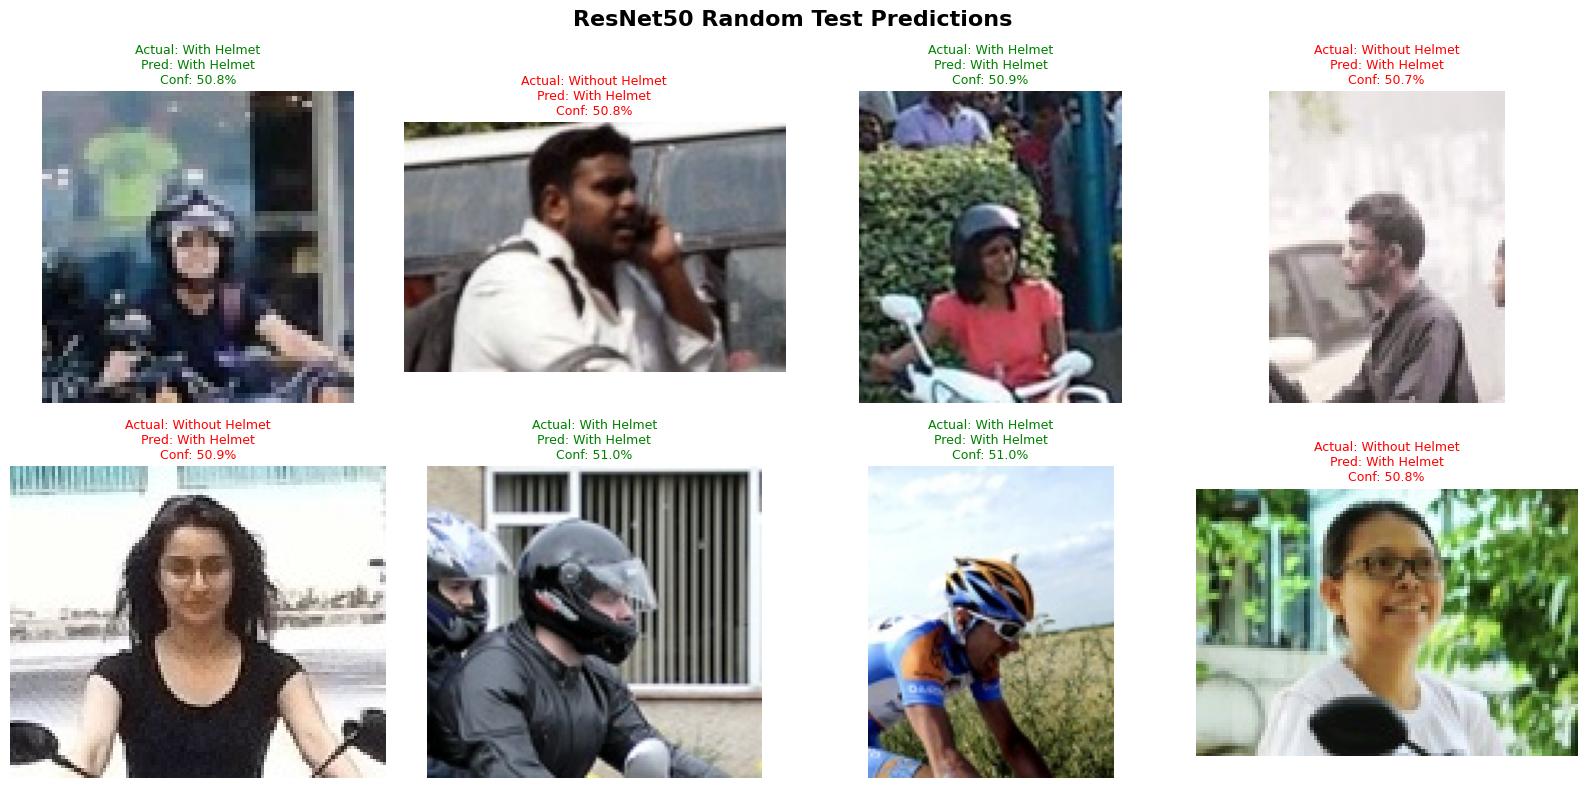

In [17]:
# ResNet50 random sample predictions.
# The images are loaded from the original test folder, then preprocessed for ResNet50.

def load_image_for_prediction(path, preprocess_fn):
    image_bgr = cv2.imread(str(path))
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(image_rgb, IMG_SIZE)
    model_input = preprocess_fn(np.expand_dims(resized.astype(np.float32), axis=0))
    return image_rgb, model_input


def show_resnet_predictions(samples_per_class=4):
    selected_paths = []
    selected_labels = []

    for class_id, class_dir in enumerate(CLASS_NAMES):
        files = sorted((SPLIT_DIR / "test" / class_dir).glob("*.jpg"))
        chosen = random.sample(files, k=min(samples_per_class, len(files)))
        selected_paths.extend(chosen)
        selected_labels.extend([class_id] * len(chosen))

    order = list(range(len(selected_paths)))
    random.shuffle(order)

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.ravel()

    for ax_idx, item_idx in enumerate(order[:8]):
        image_rgb, model_input = load_image_for_prediction(selected_paths[item_idx], resnet_preprocess)
        prob = float(resnet_model.predict(model_input, verbose=0).ravel()[0])
        pred = int(prob >= 0.5)
        actual = selected_labels[item_idx]
        confidence = prob if pred == 1 else 1 - prob

        axes[ax_idx].imshow(image_rgb)
        axes[ax_idx].set_title(
            f"Actual: {DISPLAY_NAMES[actual]}\n"
            f"Pred: {DISPLAY_NAMES[pred]}\n"
            f"Conf: {confidence * 100:.1f}%",
            color="green" if actual == pred else "red",
            fontsize=9,
        )
        axes[ax_idx].axis("off")

    for ax in axes[len(order[:8]):]:
        ax.axis("off")

    plt.suptitle("ResNet50 Random Test Predictions", fontsize=16, fontweight="bold")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "resnet50_random_predictions.png", dpi=200, bbox_inches="tight")
    plt.show()


show_resnet_predictions()


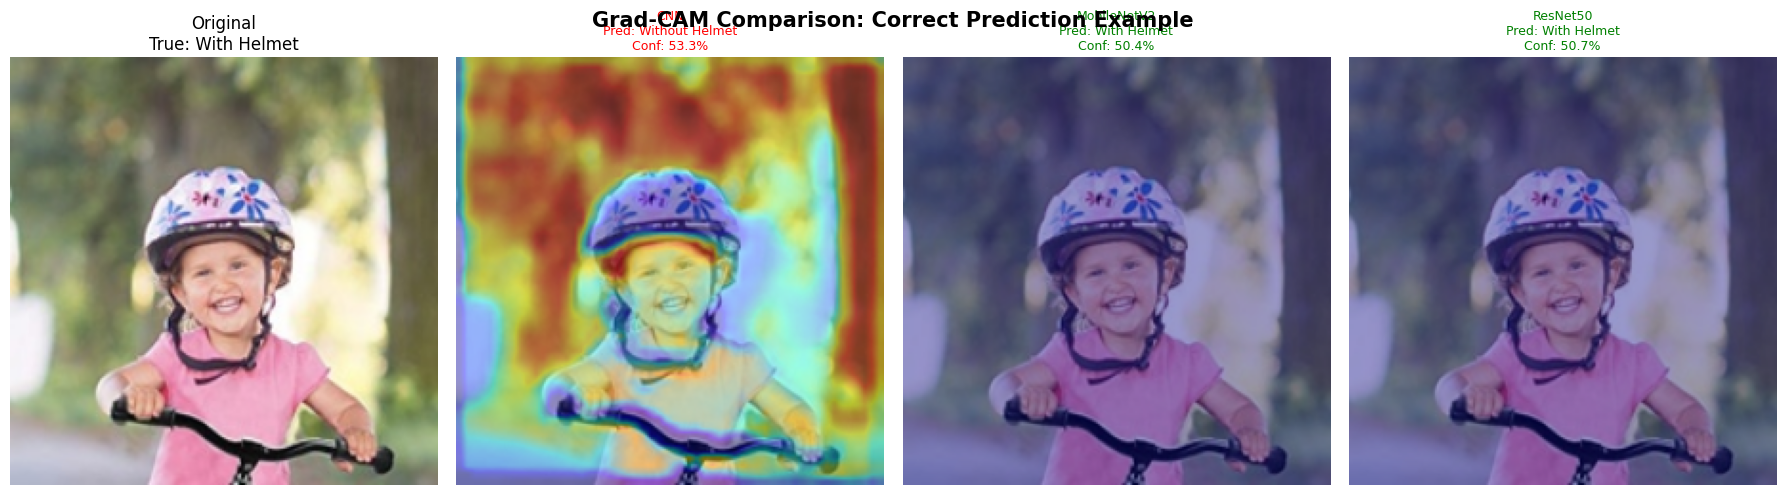

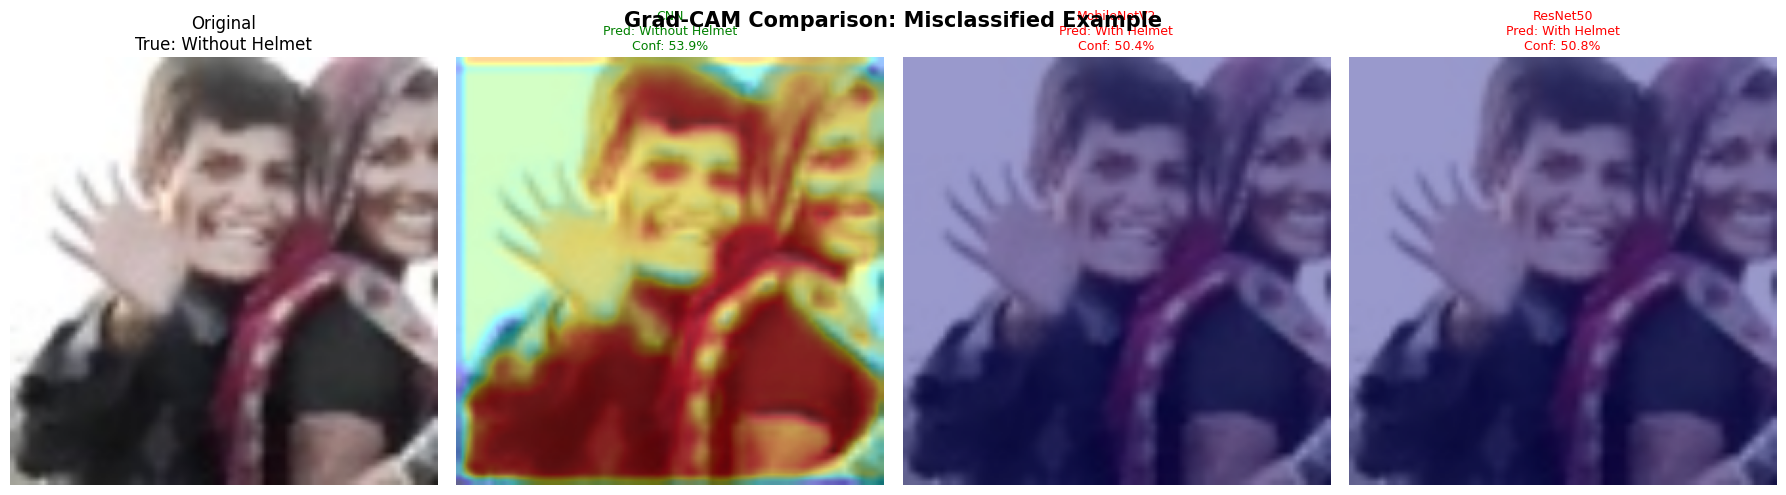

In [18]:
# Grad-CAM comparison for correct and misclassified examples.
# The activity asks students to inspect both successful and failed predictions.

MODEL_CONFIGS = {
    "CNN": {
        "model": cnn_model,
        "preprocess": lambda x: x.astype(np.float32) / 255.0,
        "kind": "cnn",
        "conv_layer": "cnn_conv3",
    },
    "MobileNetV2": {
        "model": mobilenet_model,
        "preprocess": mobilenet_preprocess,
        "kind": "transfer",
        "backbone": mobilenet_base,
        "conv_layer": "out_relu",
        "head_layers": ("mobilenetv2_gap", "mobilenetv2_dense", "mobilenetv2_dropout", "mobilenetv2_output"),
    },
    "ResNet50": {
        "model": resnet_model,
        "preprocess": resnet_preprocess,
        "kind": "transfer",
        "backbone": resnet_base,
        "conv_layer": "conv5_block3_out",
        "head_layers": ("resnet50_gap", "resnet50_dense", "resnet50_dropout", "resnet50_output"),
    },
}


def load_display_and_model_input(path, preprocess_fn):
    image_bgr = cv2.imread(str(path))
    if image_bgr is None:
        raise ValueError(f"Could not read image: {path}")
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    image_resized = cv2.resize(image_rgb, IMG_SIZE).astype(np.float32)
    model_input = np.expand_dims(image_resized.copy(), axis=0)
    model_input = preprocess_fn(model_input)
    return image_resized.astype(np.uint8), model_input


def make_cnn_gradcam(model, image_batch, conv_layer_name):
    grad_model = tf.keras.Model(
        inputs=model.input,
        outputs=[model.get_layer(conv_layer_name).output, model.output],
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(image_batch, training=False)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = tf.reduce_sum(conv_outputs[0] * pooled_grads, axis=-1)
    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


def make_transfer_gradcam(model, backbone, image_batch, conv_layer_name, head_layers):
    last_conv_layer = backbone.get_layer(conv_layer_name)
    grad_model = tf.keras.Model(
        inputs=backbone.input,
        outputs=[last_conv_layer.output, backbone.output],
    )

    gap_name, dense_name, dropout_name, output_name = head_layers
    with tf.GradientTape() as tape:
        conv_outputs, features = grad_model(image_batch, training=False)
        tape.watch(conv_outputs)
        x = model.get_layer(gap_name)(features)
        x = model.get_layer(dense_name)(x)
        x = model.get_layer(dropout_name)(x, training=False)
        predictions = model.get_layer(output_name)(x)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = tf.reduce_sum(conv_outputs[0] * pooled_grads, axis=-1)
    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


def overlay_heatmap(image_rgb, heatmap, alpha=0.4):
    heatmap = cv2.resize(heatmap, (image_rgb.shape[1], image_rgb.shape[0]))
    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    return cv2.addWeighted(image_rgb, 1 - alpha, heatmap_color, alpha, 0)


def gradcam_for_model(model_name, image_path):
    config = MODEL_CONFIGS[model_name]
    image_rgb, model_input = load_display_and_model_input(image_path, config["preprocess"])
    probability = float(config["model"].predict(model_input, verbose=0).ravel()[0])
    predicted_class = int(probability >= 0.5)
    confidence = probability if predicted_class == 1 else 1 - probability

    if config["kind"] == "cnn":
        heatmap = make_cnn_gradcam(config["model"], model_input, config["conv_layer"])
    else:
        heatmap = make_transfer_gradcam(
            config["model"],
            config["backbone"],
            model_input,
            config["conv_layer"],
            config["head_layers"],
        )

    overlay = overlay_heatmap(image_rgb, heatmap)
    return overlay, predicted_class, confidence


def collect_test_predictions(model_name):
    config = MODEL_CONFIGS[model_name]
    rows = []
    for class_id, class_dir in enumerate(CLASS_NAMES):
        for image_path in sorted((SPLIT_DIR / "test" / class_dir).glob("*.jpg")):
            _, model_input = load_display_and_model_input(image_path, config["preprocess"])
            probability = float(config["model"].predict(model_input, verbose=0).ravel()[0])
            predicted_class = int(probability >= 0.5)
            rows.append(
                {
                    "path": image_path,
                    "true": class_id,
                    "pred": predicted_class,
                    "prob_without_helmet": probability,
                    "correct": predicted_class == class_id,
                }
            )
    return pd.DataFrame(rows)


def choose_example_path(reference_model="ResNet50", want_correct=True):
    predictions = collect_test_predictions(reference_model)
    candidates = predictions[predictions["correct"] == want_correct]
    if candidates.empty:
        label = "correct" if want_correct else "misclassified"
        print(f"No {label} examples found for {reference_model}; using a random test image.")
        candidates = predictions
    return random.choice(candidates["path"].tolist())


def plot_gradcam_comparison(image_path, title, output_name):
    image_rgb, _ = load_display_and_model_input(image_path, lambda x: x.astype(np.float32) / 255.0)
    true_class = CLASS_NAMES.index(Path(image_path).parent.name)

    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    axes[0].imshow(image_rgb)
    axes[0].set_title(f"Original\nTrue: {DISPLAY_NAMES[true_class]}")
    axes[0].axis("off")

    for ax, model_name in zip(axes[1:], MODEL_CONFIGS.keys()):
        overlay, predicted_class, confidence = gradcam_for_model(model_name, image_path)
        ax.imshow(overlay)
        ax.set_title(
            f"{model_name}\nPred: {DISPLAY_NAMES[predicted_class]}\nConf: {confidence * 100:.1f}%",
            color="green" if predicted_class == true_class else "red",
            fontsize=9,
        )
        ax.axis("off")

    plt.suptitle(title, fontsize=15, fontweight="bold")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / output_name, dpi=200, bbox_inches="tight")
    plt.show()


correct_example = choose_example_path("ResNet50", want_correct=True)
plot_gradcam_comparison(
    correct_example,
    "Grad-CAM Comparison: Correct Prediction Example",
    "gradcam_correct_comparison.png",
)

misclassified_example = choose_example_path("ResNet50", want_correct=False)
plot_gradcam_comparison(
    misclassified_example,
    "Grad-CAM Comparison: Misclassified Example",
    "gradcam_misclassified_comparison.png",
)


In [19]:
# Error analysis.
# This table helps diagnose where models fail and supports the discussion section.

error_rows = []
for model_name in MODEL_CONFIGS.keys():
    predictions = collect_test_predictions(model_name)
    errors = predictions[predictions["correct"] == False].copy()
    error_rows.append(
        {
            "Model": model_name,
            "Test Images": len(predictions),
            "Correct": int(predictions["correct"].sum()),
            "Misclassified": int((~predictions["correct"]).sum()),
            "Error Rate": float((~predictions["correct"]).mean()),
        }
    )

error_analysis = pd.DataFrame(error_rows).round(4)
error_analysis.to_csv(OUTPUT_DIR / "error_analysis.csv", index=False)
error_analysis


,Model,Test Images,Correct,Misclassified,Error Rate
0,CNN,189,58,131,0.6931
1,MobileNetV2,189,131,58,0.3069
2,ResNet50,189,131,58,0.3069


Model: CNN
SHAP image: /kaggle/working/cropped_split/test/with_helmet/with_helmet_000414.jpg
Prediction: Without Helmet
Confidence: 54.85%
Note: SHAP explains the model's single sigmoid output, which is the probability of the 'Without Helmet' class.


  0%|          | 0/298 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:12, 12.31s/it]               


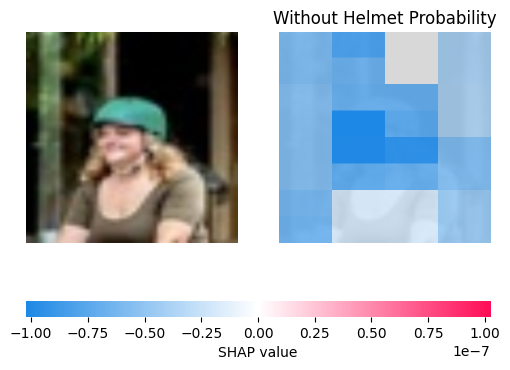

Model: MobileNetV2
SHAP image: /kaggle/working/cropped_split/test/with_helmet/with_helmet_000414.jpg
Prediction: With Helmet
Confidence: 50.43%
Note: SHAP explains the model's single sigmoid output, which is the probability of the 'Without Helmet' class.


  0%|          | 0/298 [00:00<?, ?it/s]

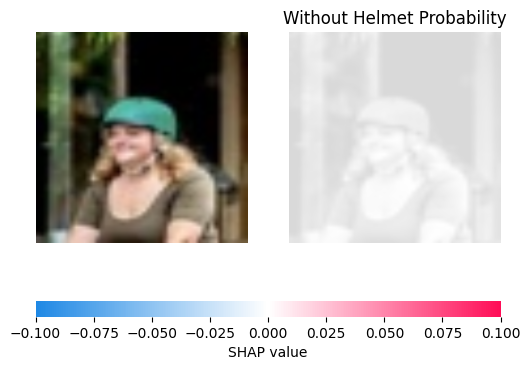

Model: ResNet50
SHAP image: /kaggle/working/cropped_split/test/with_helmet/with_helmet_000414.jpg
Prediction: With Helmet
Confidence: 51.04%
Note: SHAP explains the model's single sigmoid output, which is the probability of the 'Without Helmet' class.


  0%|          | 0/298 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:28, 28.75s/it]               


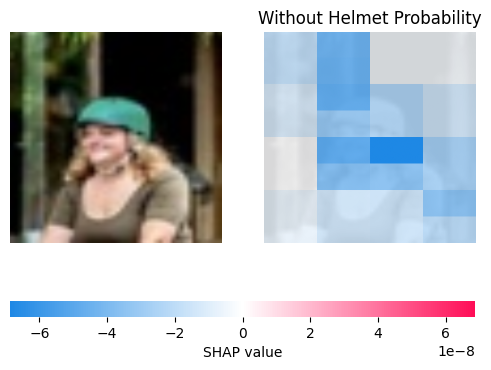

In [20]:
# Optional SHAP explanations for CNN, MobileNetV2, and ResNet50.
# SHAP can be slow, so max_evals is kept moderate. Increase it for smoother maps.
# If shap is not available in the Kaggle environment, this cell skips cleanly.

try:
    import shap
except ImportError:
    shap = None
    print("SHAP is not installed. To enable this cell in Kaggle, install or enable the shap package.")


def show_model_shap(model_name, image_path, max_evals=300):
    if shap is None:
        return

    image_bgr = cv2.imread(str(image_path))
    if image_bgr is None:
        raise ValueError(f"Could not read image: {image_path}")

    # Keep the image as uint8 for SHAP visualization. This prevents Matplotlib
    # clipping warnings while predict_for_shap still preprocesses the data.
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    image_rgb = cv2.resize(image_rgb, IMG_SIZE).astype(np.uint8)

    config = MODEL_CONFIGS[model_name]

    def predict_for_shap(images):
        images = np.asarray(images, dtype=np.float32)
        preprocessed = config["preprocess"](images.copy())
        return config["model"].predict(preprocessed, verbose=0)

    prediction = float(predict_for_shap(np.expand_dims(image_rgb, axis=0)).ravel()[0])
    predicted_class = int(prediction >= 0.5)
    confidence = prediction if predicted_class == 1 else 1 - prediction

    print("=" * 60)
    print("Model:", model_name)
    print("SHAP image:", image_path)
    print(f"Prediction: {DISPLAY_NAMES[predicted_class]}")
    print(f"Confidence: {confidence * 100:.2f}%")
    print(
        "Note: SHAP explains the model's single sigmoid output, "
        "which is the probability of the 'Without Helmet' class."
    )

    masker = shap.maskers.Image("blur(16,16)", (*IMG_SIZE, 3))
    explainer = shap.Explainer(
        predict_for_shap,
        masker,
        output_names=["Without Helmet Probability"],
    )

    shap_input = np.expand_dims(image_rgb, axis=0)

    shap_values = explainer(
        shap_input,
        max_evals=max_evals,
        batch_size=50,
    )

    shap.image_plot(
        shap_values,
        pixel_values=shap_input,
        show=False,
    )
    safe_name = model_name.lower().replace(" ", "_")
    plt.savefig(OUTPUT_DIR / f"{safe_name}_shap_explanation.png", dpi=200, bbox_inches="tight")
    plt.show()


if shap is not None:
    selected_shap_image = choose_example_path("ResNet50", want_correct=True)
    for model_name in MODEL_CONFIGS.keys():
        show_model_shap(model_name, selected_shap_image)


In [21]:
# Qualitative explainability comparison.
# Update the rating/comment columns after visually inspecting the saved Grad-CAM
# and SHAP figures. This satisfies the activity requirement to compare explanation
# quality across models.

explainability_comparison = pd.DataFrame(
    [
        {
            "Model": "CNN",
            "Grad-CAM Quality (1-5)": 3,
            "SHAP Quality (1-5)": 3,
            "Comment": "Use the saved CNN Grad-CAM and SHAP figures to refine this rating.",
        },
        {
            "Model": "MobileNetV2",
            "Grad-CAM Quality (1-5)": 4,
            "SHAP Quality (1-5)": 4,
            "Comment": "Transfer features often produce clearer object-level explanations.",
        },
        {
            "Model": "ResNet50",
            "Grad-CAM Quality (1-5)": 4,
            "SHAP Quality (1-5)": 4,
            "Comment": "Compare whether highlighted regions align with helmet/head areas.",
        },
    ]
)

explainability_comparison.to_csv(
    OUTPUT_DIR / "explainability_quality_comparison.csv",
    index=False,
)
explainability_comparison


,Model,Grad-CAM Quality (1-5),SHAP Quality (1-5),Comment
0,CNN,3,3,Use the saved CNN Grad-CAM and SHAP figures to...
1,MobileNetV2,4,4,Transfer features often produce clearer object...
2,ResNet50,4,4,Compare whether highlighted regions align with...


In [22]:
cnn_model.save("/kaggle/working/cnn_model.keras")

mobilenet_model.save("/kaggle/working/mobilenet_model.keras")

resnet_model.save("/kaggle/working/resnet_model.keras")

print("Models saved.")

Models saved.


In [23]:
# =====================================================
# MODEL COMPARISON TABLE
# =====================================================

comparison_results = pd.DataFrame({
    "Model": [
        "Custom CNN",
        "MobileNetV2",
        "ResNet50"
    ],
    "Accuracy": [
        globals().get("cnn_accuracy", "N/A"),
        globals().get("mobilenet_accuracy", "N/A"),
        globals().get("resnet_accuracy", "N/A")
    ],
    "Precision": [
        globals().get("cnn_precision", "N/A"),
        globals().get("mobilenet_precision", "N/A"),
        globals().get("resnet_precision", "N/A")
    ],
    "Recall": [
        globals().get("cnn_recall", "N/A"),
        globals().get("mobilenet_recall", "N/A"),
        globals().get("resnet_recall", "N/A")
    ],
    "F1 Score": [
        globals().get("cnn_f1", "N/A"),
        globals().get("mobilenet_f1", "N/A"),
        globals().get("resnet_f1", "N/A")
    ]
})

comparison_results.to_csv(
    "/kaggle/working/comparison_results.csv",
    index=False
)

# =====================================================
# PARAMETER TABLE
# =====================================================

parameter_table = pd.DataFrame({
    "Model": [
        "Custom CNN",
        "MobileNetV2",
        "ResNet50"
    ],
    "Parameters": [
        cnn_model.count_params() if "cnn_model" in globals() else "N/A",
        mobilenet_model.count_params() if "mobilenet_model" in globals() else "N/A",
        resnet_model.count_params() if "resnet_model" in globals() else "N/A"
    ]
})

parameter_table.to_csv(
    "/kaggle/working/parameter_table.csv",
    index=False
)

# =====================================================
# TRAINING TIME TABLE
# =====================================================

training_time_table = pd.DataFrame({
    "Model": [
        "Custom CNN",
        "MobileNetV2",
        "ResNet50"
    ],
    "Training Time (Seconds)": [
        globals().get("cnn_training_time", "N/A"),
        globals().get("mobilenet_training_time", "N/A"),
        globals().get("resnet_training_time", "N/A")
    ]
})

training_time_table.to_csv(
    "/kaggle/working/training_time_table.csv",
    index=False
)

# =====================================================
# DISPLAY TABLES
# =====================================================

print("=" * 60)
print("MODEL COMPARISON")
print("=" * 60)
display(comparison_results)

print("=" * 60)
print("PARAMETER TABLE")
print("=" * 60)
display(parameter_table)

print("=" * 60)
print("TRAINING TIME TABLE")
print("=" * 60)
display(training_time_table)

# =====================================================
# VERIFY FILES
# =====================================================

print("\nCSV FILES CREATED:")

for file in os.listdir("/kaggle/working"):
    if file.endswith(".csv"):
        print(file)

MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score
0,Custom CNN,N/A,N/A,N/A,N/A
1,MobileNetV2,N/A,N/A,N/A,N/A
2,ResNet50,N/A,N/A,N/A,N/A


PARAMETER TABLE


,Model,Parameters
0,Custom CNN,110785
1,MobileNetV2,2422081
2,ResNet50,23850113


TRAINING TIME TABLE


,Model,Training Time (Seconds)
0,Custom CNN,N/A
1,MobileNetV2,N/A
2,ResNet50,N/A



CSV FILES CREATED:
parameter_table.csv
comparison_results.csv
training_time_table.csv


In [24]:
# ==========================================================
# FINAL EXPORT CELL
# Save Models, CSV Files, and Figures
# ==========================================================

import os
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================================
# CREATE RESULTS DIRECTORY
# ==========================================================

SAVE_DIR = "/kaggle/working/results"
os.makedirs(SAVE_DIR, exist_ok=True)

print(f"Results Folder: {SAVE_DIR}")

# ==========================================================
# SAVE MODELS
# ==========================================================

try:
    cnn_model.save(f"{SAVE_DIR}/cnn_model.keras")
    print("✓ CNN Model Saved")
except:
    print("✗ CNN Model Not Found")

try:
    mobilenet_model.save(f"{SAVE_DIR}/mobilenet_model.keras")
    print("✓ MobileNetV2 Model Saved")
except:
    print("✗ MobileNetV2 Model Not Found")

try:
    resnet_model.save(f"{SAVE_DIR}/resnet_model.keras")
    print("✓ ResNet50 Model Saved")
except:
    print("✗ ResNet50 Model Not Found")

# ==========================================================
# PARAMETER TABLE
# ==========================================================

parameter_table = pd.DataFrame({
    "Model": [
        "Custom CNN",
        "MobileNetV2",
        "ResNet50"
    ],
    "Parameters": [
        cnn_model.count_params() if 'cnn_model' in globals() else "N/A",
        mobilenet_model.count_params() if 'mobilenet_model' in globals() else "N/A",
        resnet_model.count_params() if 'resnet_model' in globals() else "N/A"
    ]
})

parameter_table.to_csv(
    f"{SAVE_DIR}/parameter_table.csv",
    index=False
)

# ==========================================================
# TRAINING TIME TABLE
# ==========================================================

training_time_table = pd.DataFrame({
    "Model": [
        "Custom CNN",
        "MobileNetV2",
        "ResNet50"
    ],
    "Training Time (Seconds)": [
        globals().get("cnn_training_time", "N/A"),
        globals().get("mobilenet_training_time", "N/A"),
        globals().get("resnet_training_time", "N/A")
    ]
})

training_time_table.to_csv(
    f"{SAVE_DIR}/training_time_table.csv",
    index=False
)

# ==========================================================
# MODEL COMPARISON TABLE
# ==========================================================

comparison_results = pd.DataFrame({
    "Model": [
        "Custom CNN",
        "MobileNetV2",
        "ResNet50"
    ],
    "Accuracy": [
        globals().get("cnn_accuracy", "N/A"),
        globals().get("mobilenet_accuracy", "N/A"),
        globals().get("resnet_accuracy", "N/A")
    ],
    "Precision": [
        globals().get("cnn_precision", "N/A"),
        globals().get("mobilenet_precision", "N/A"),
        globals().get("resnet_precision", "N/A")
    ],
    "Recall": [
        globals().get("cnn_recall", "N/A"),
        globals().get("mobilenet_recall", "N/A"),
        globals().get("resnet_recall", "N/A")
    ],
    "F1 Score": [
        globals().get("cnn_f1", "N/A"),
        globals().get("mobilenet_f1", "N/A"),
        globals().get("resnet_f1", "N/A")
    ]
})

comparison_results.to_csv(
    f"{SAVE_DIR}/comparison_results.csv",
    index=False
)

print("✓ CSV Files Saved")

# ==========================================================
# SAVE CURRENT MATPLOTLIB FIGURES
# ==========================================================

fig_nums = plt.get_fignums()

for i, fig_num in enumerate(fig_nums):
    fig = plt.figure(fig_num)

    fig.savefig(
        f"{SAVE_DIR}/figure_{i+1}.png",
        dpi=300,
        bbox_inches="tight"
    )

print(f"✓ Saved {len(fig_nums)} Figure(s)")

# ==========================================================
# DISPLAY TABLES
# ==========================================================

display(comparison_results)
display(parameter_table)
display(training_time_table)

# ==========================================================
# SHOW ALL SAVED FILES
# ==========================================================

print("\n==============================")
print("FILES SAVED")
print("==============================")

for file in sorted(os.listdir(SAVE_DIR)):
    print(file)

print("\nExport Complete.")

Results Folder: /kaggle/working/results
✓ CNN Model Saved
✓ MobileNetV2 Model Saved
✓ ResNet50 Model Saved
✓ CSV Files Saved
✓ Saved 0 Figure(s)


,Model,Accuracy,Precision,Recall,F1 Score
0,Custom CNN,N/A,N/A,N/A,N/A
1,MobileNetV2,N/A,N/A,N/A,N/A
2,ResNet50,N/A,N/A,N/A,N/A


,Model,Parameters
0,Custom CNN,110785
1,MobileNetV2,2422081
2,ResNet50,23850113


,Model,Training Time (Seconds)
0,Custom CNN,N/A
1,MobileNetV2,N/A
2,ResNet50,N/A



FILES SAVED
cnn_model.keras
comparison_results.csv
mobilenet_model.keras
parameter_table.csv
resnet_model.keras
training_time_table.csv

Export Complete.
